## Proof of Concept 1 - nouvelles méthodes de détection de manoeuvres

### On reprend ici le cas de 5 satellites dont les manoeuvres ont été mal déterminées et on leur applique notre analyse.

In [1]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
from viz.time_series import (
LABELS,
plot_time_series,
plot_compare,
save_fig
)
from maneuver_detection.compare import compare_methods
from maneuver_detection.discrete_kalman_filter import detect_kalman, kalman_filter_ordre_1, kalman_filter_ordre_2
def find_root(marker: str = "pyproject.toml"):
    p = Path.cwd().resolve()
    for parent in (p, *p.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"{marker} introuvable en remontant depuis {p}")
ROOT = find_root()
OUTPUT = ROOT / "data" / "graphs"
## Les différents paramètres récupérés via les TLE SpaceTrack (11 paramètres)
print(LABELS.keys())




FIG_DIR = ROOT / "caractérisation_manoeuvres" 



dict_keys(['sma', 'eccentricity', 'inclination', 'raan', 'arg_perigee', 'mean_anomaly', 'mean_motion', 'period', 'velocity', 'rev_at_epoch', 'bstar'])


In [ ]:
## Code de recup des figures d'interet. 

def poc_new_methods(path, norad, ordre= 1, r=0.5, var_Q = 0.013, alpha= 0.997, in_plane=True, out_plane=True): 

    norad=norad

    norads= pl.scan_parquet(path).select('norad').unique().sort('norad').collect().to_series().to_list()


    print(f"Norad {norad} in path : {norad in norads}")
    df = (
        pl.scan_parquet(path).filter(pl.col('norad') == norad)
        .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
        .sort('epoch').collect()
        )
    if in_plane : 

        epoch, sma_dot_dot, nis, maneuvers, treshold =  detect_kalman(df, ordre = ordre, r=r, var_Q=var_Q, alpha=alpha)
        epochs_maneuvers = epoch[maneuvers]
            
        fig1 = plot_time_series(path, norad, 'sma', maneuvers=epochs_maneuvers) 
        fig2 = plot_time_series(path, norad, 'eccentricity', maneuvers=epochs_maneuvers)
        fig3 = plot_time_series(path, norad, 'inclination', maneuvers=epochs_maneuvers)
        #save_fig(fig1, f"time_series_{norad}_sma")
        #save_fig(fig2, f"time_series_{norad}_eccentricity")
        #save_fig(fig3, f"time_series_{norad}_inclination")

        #detect_kalman(df, ordre=ordre, r=r, var_Q = var_Q, alpha=alpha)
        #plt.gcf().savefig(FIG_DIR / f"{norad}_detect_kalman.png", dpi=150, bbox_inches="tight")
    if out_plane:
        
        epoch_incl, incl_dot, nis_incl, maneuvers_incl, treshold_incl =  detect_kalman(df, ordre = ordre, r=r, var_Q=var_Q, alpha=alpha, metrique='inclination')
        epochs_maneuvers_incl = epoch_incl[maneuvers_incl]
        fig1 = plot_time_series(path, norad, 'sma', maneuvers=epochs_maneuvers_incl) 
        fig2 = plot_time_series(path, norad, 'eccentricity', maneuvers=epochs_maneuvers_incl)
        fig3 = plot_time_series(path, norad, 'inclination', maneuvers=epochs_maneuvers_incl)

    
    
    


Norad 63920 in path : True
Filtre Kalman 1 appliqué...


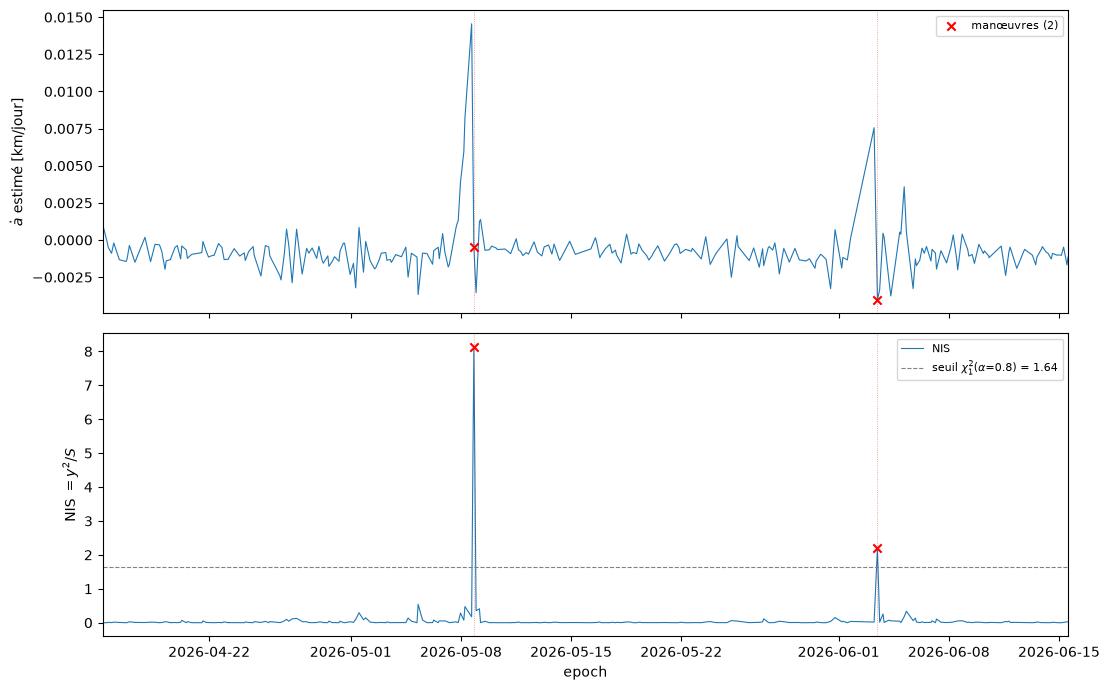

Filtre Kalman 1 appliqué...


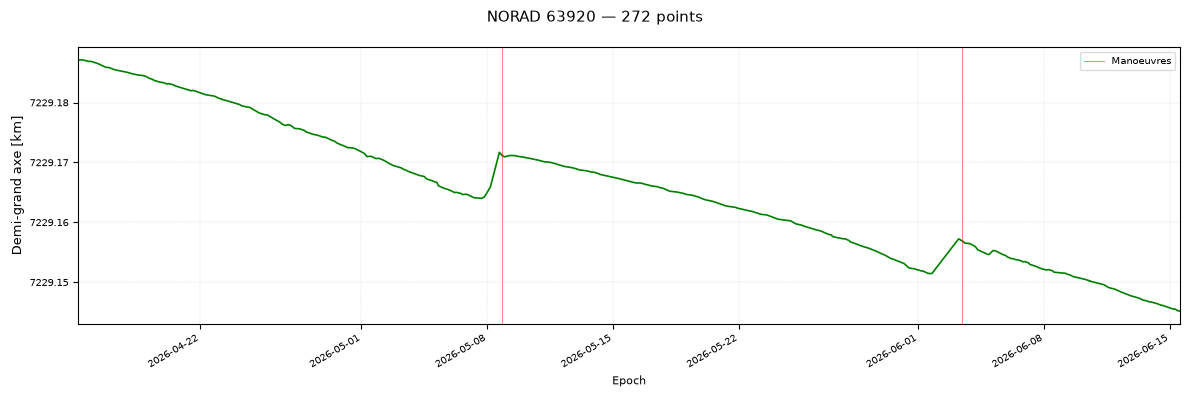

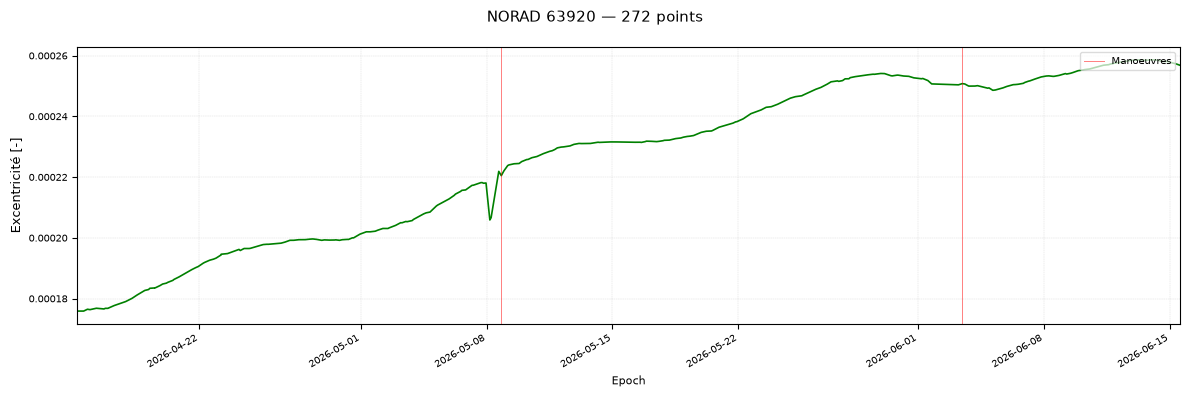

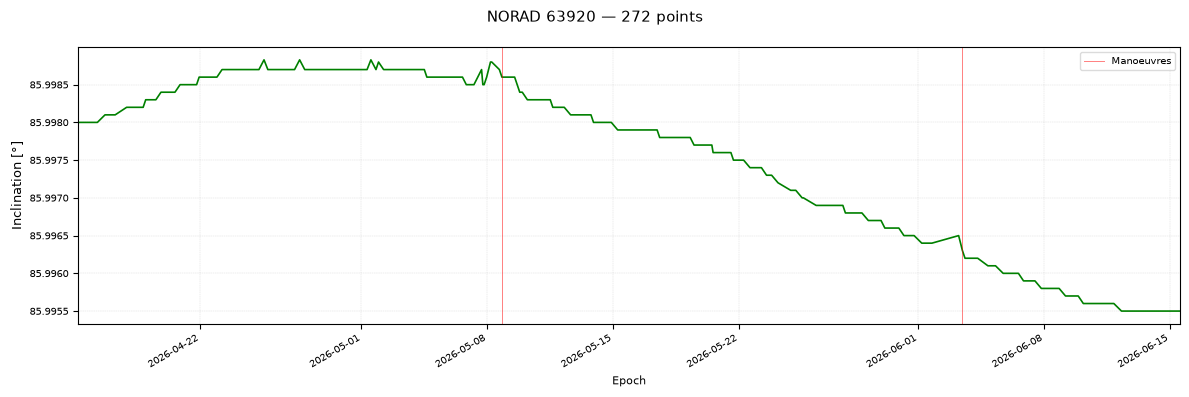

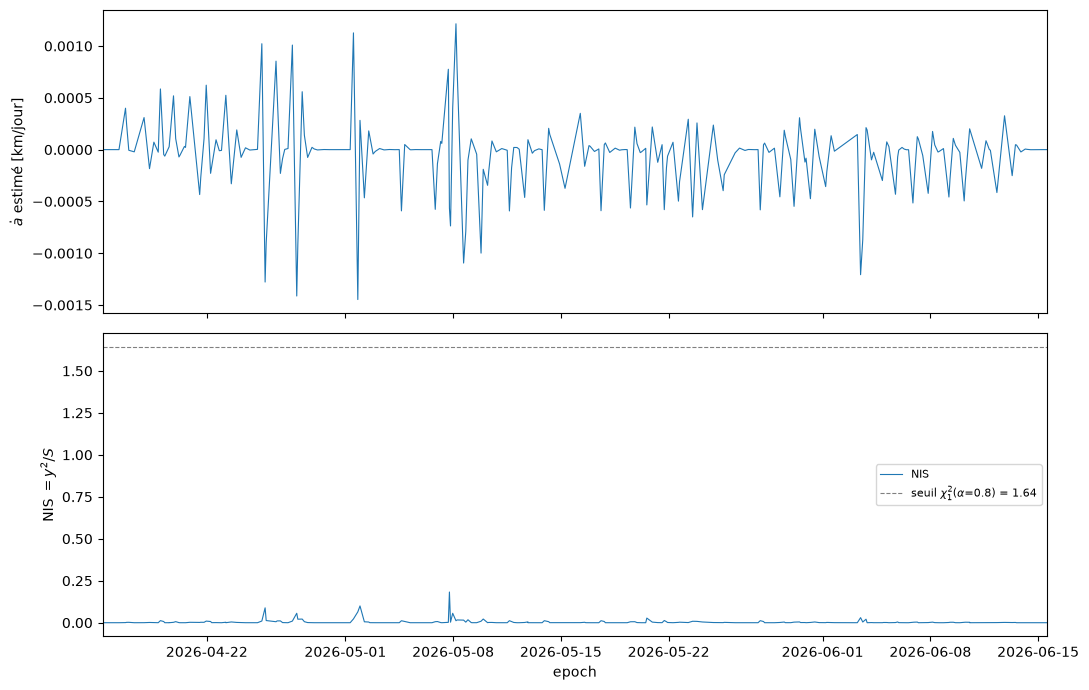

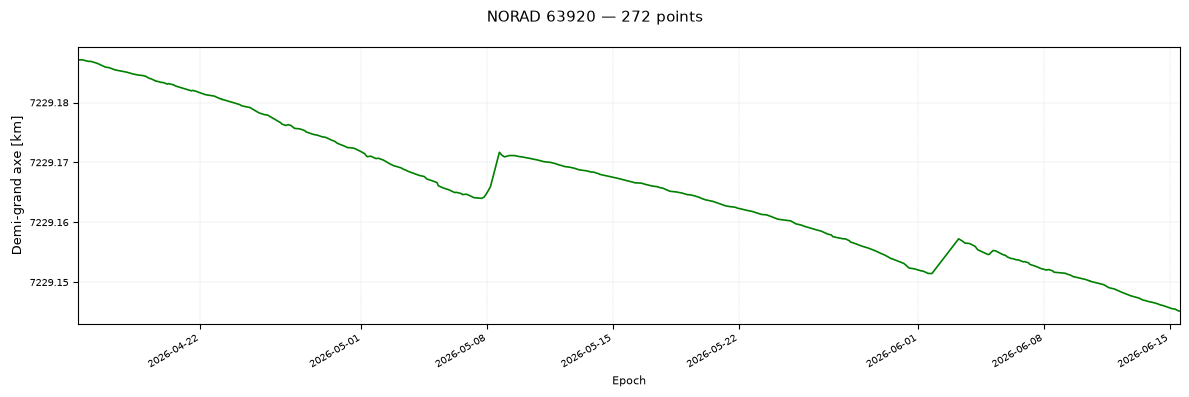

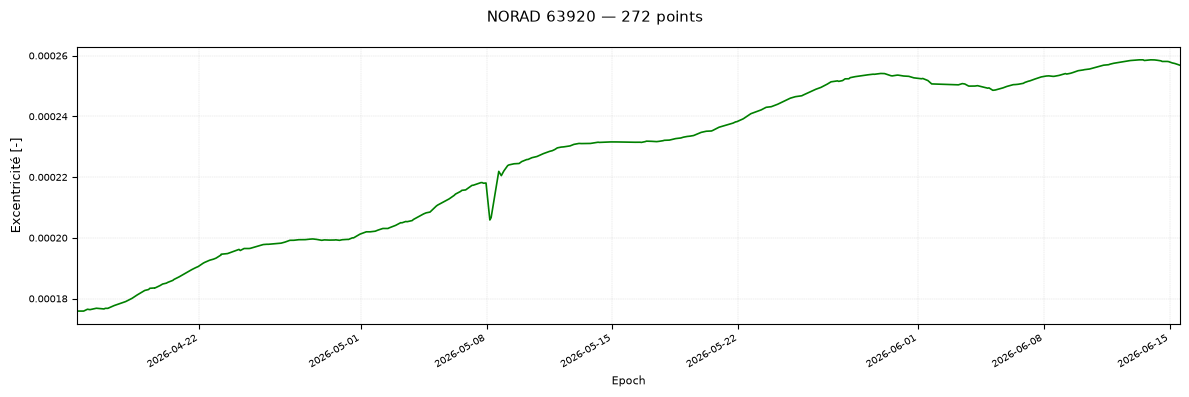

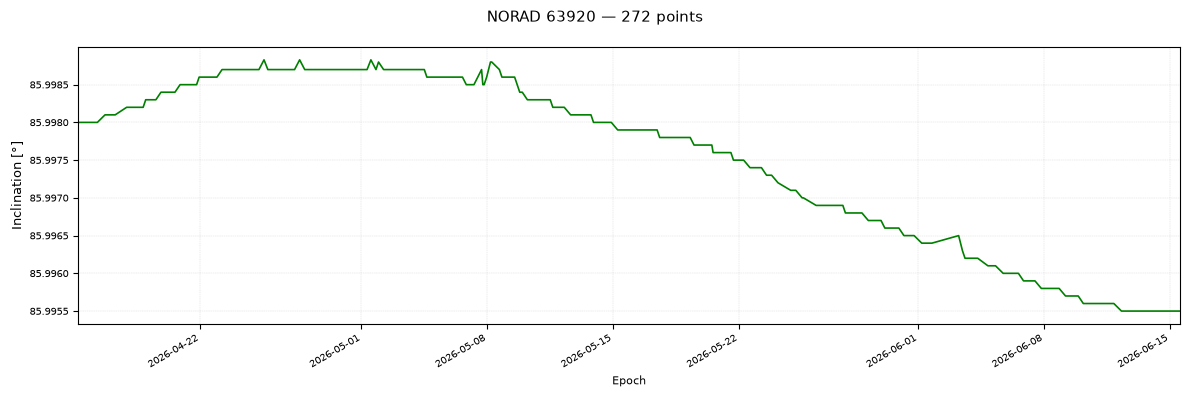

In [3]:
## YAOGAN-40 02C -  63920
path = ROOT / "data" / "raw" / "YAOGAN_ALL_1783347325.94606.parquet"

poc_new_methods(path, norad = 63920, var_Q = 0.0013, r = 1e-7, alpha=0.8)


Norad 63630 in path : True
Filtre Kalman 1 appliqué...


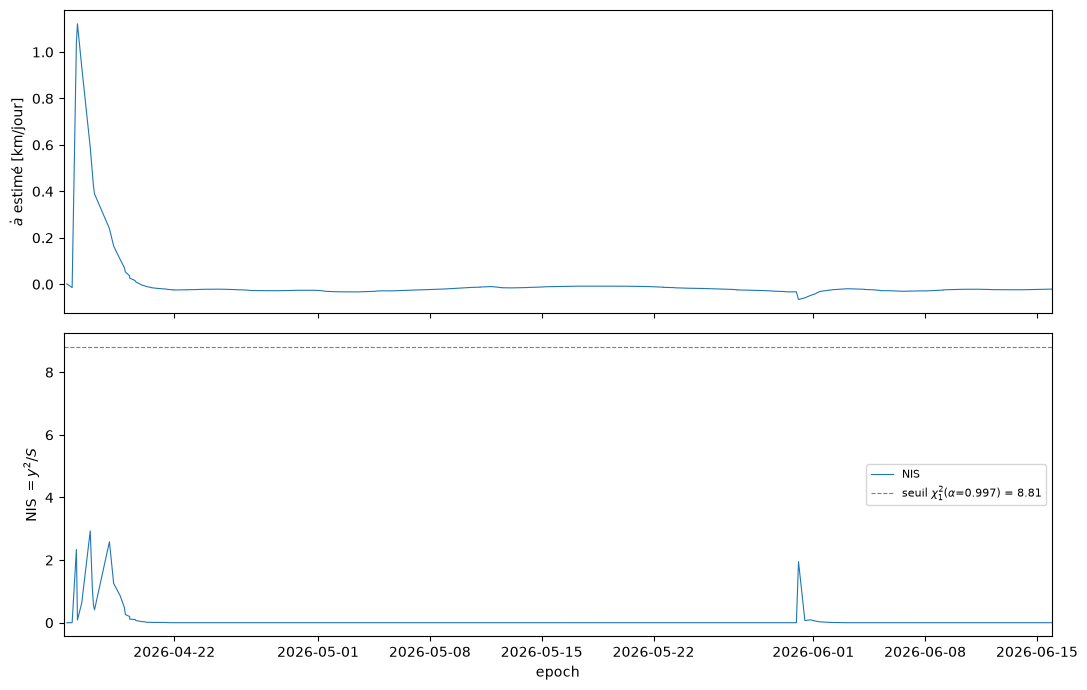

Filtre Kalman 1 appliqué...


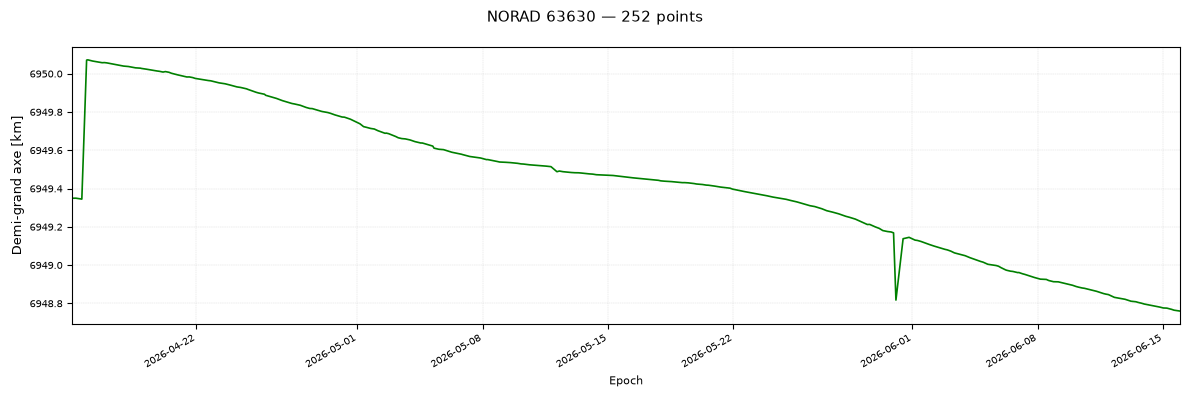

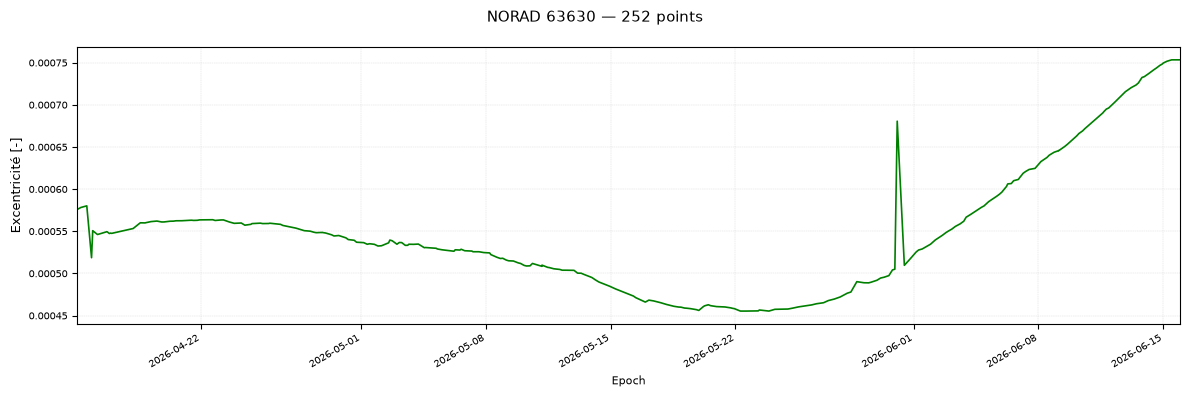

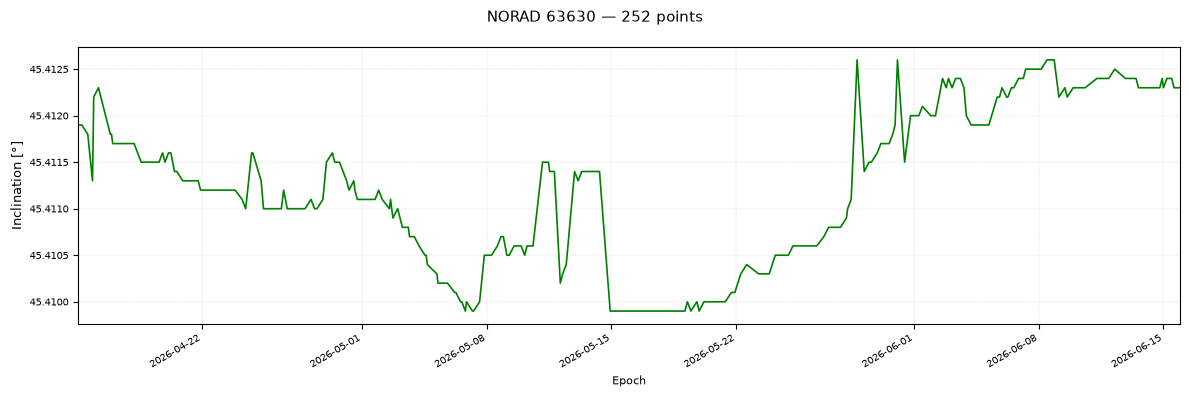

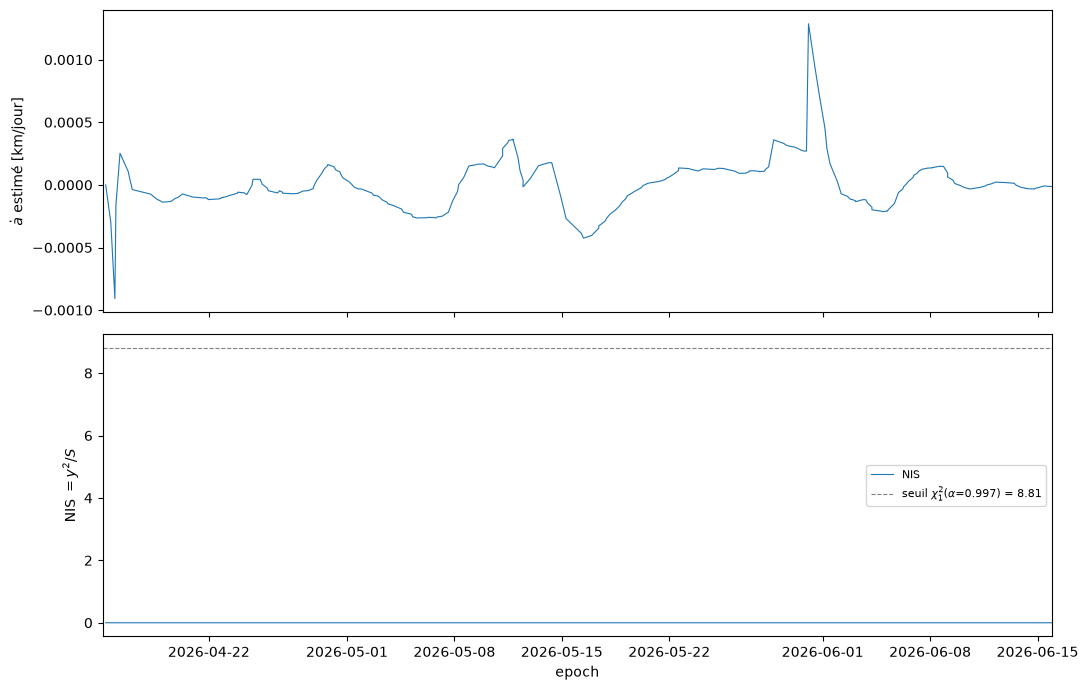

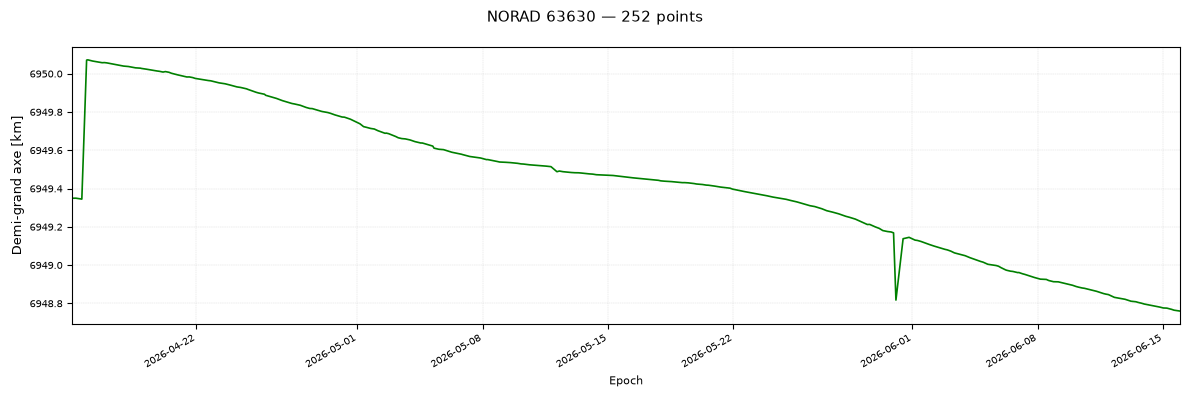

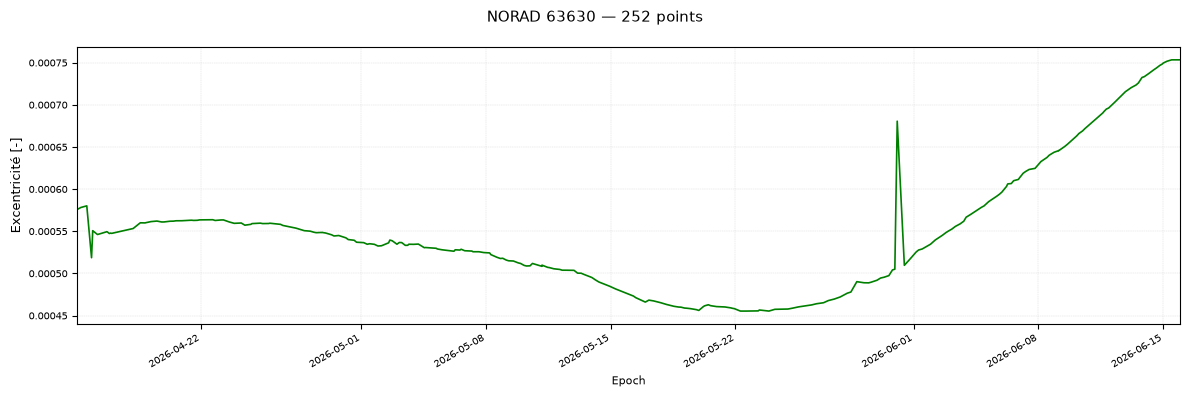

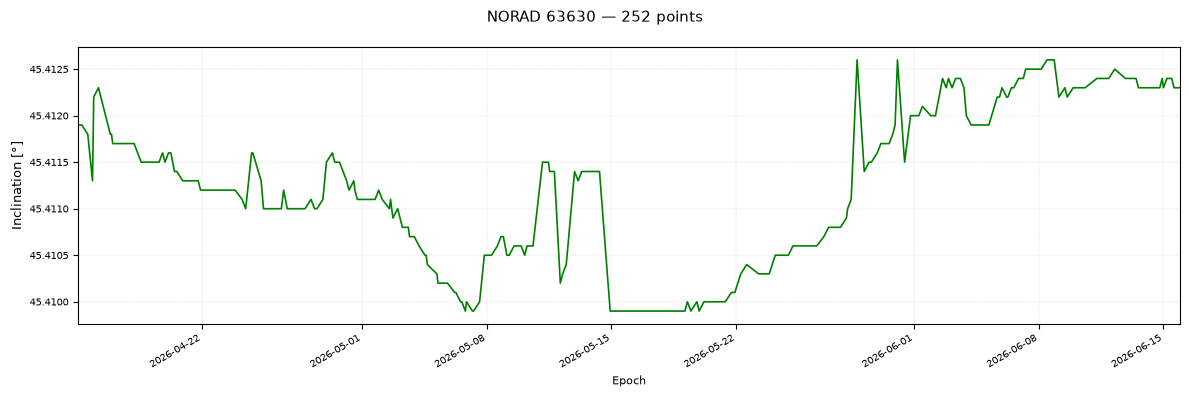

In [4]:
## KORSAT-3 - 63630

path = ROOT / "data" / "raw" / "KORSAT_ALL_1783347334.348156.parquet"

poc_new_methods(path, norad=63630, r = 0.05)



Norad 39375 in path : True
Filtre Kalman 1 appliqué...


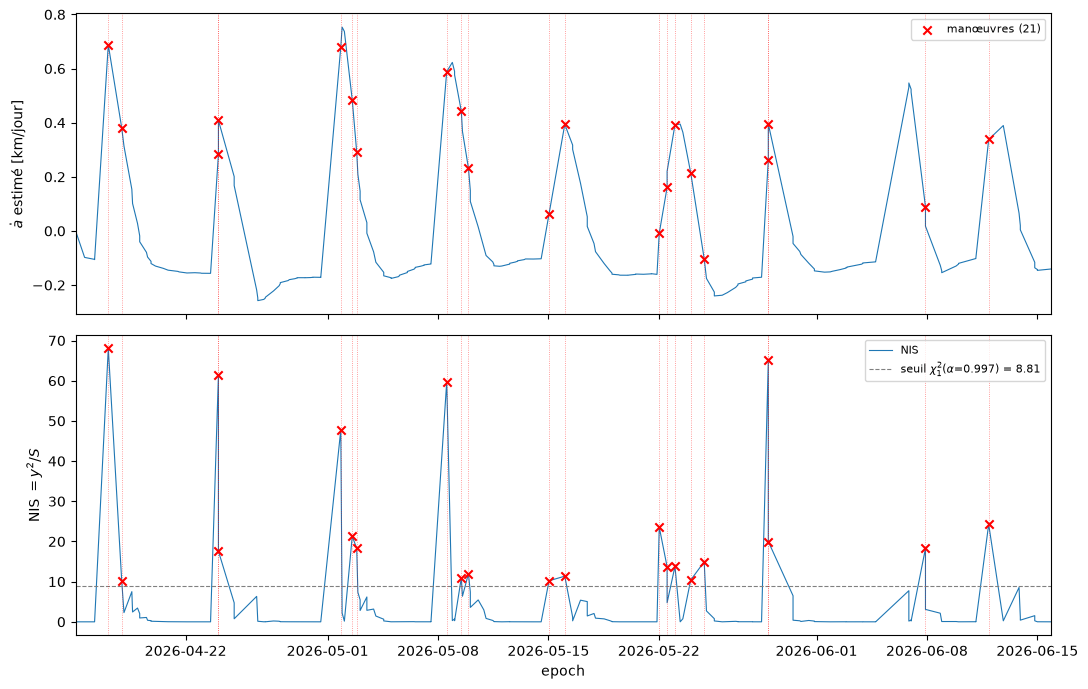

Filtre Kalman 1 appliqué...


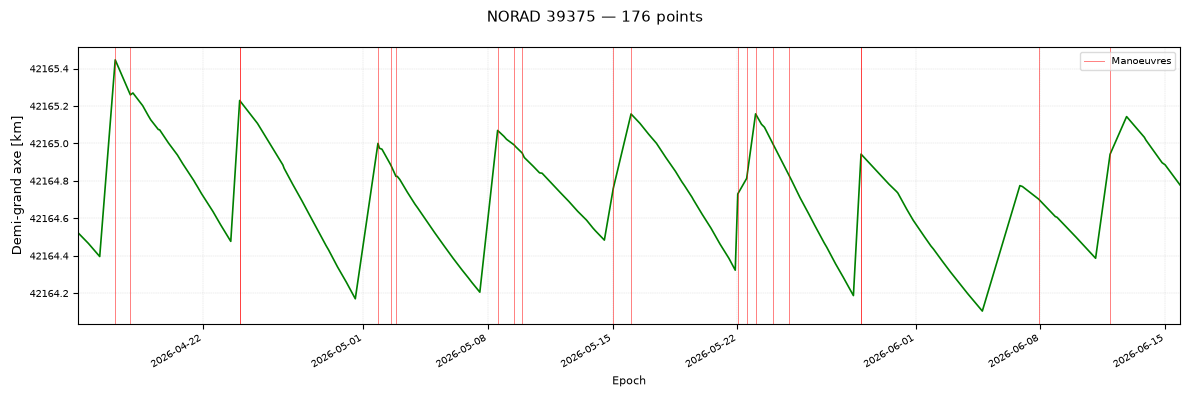

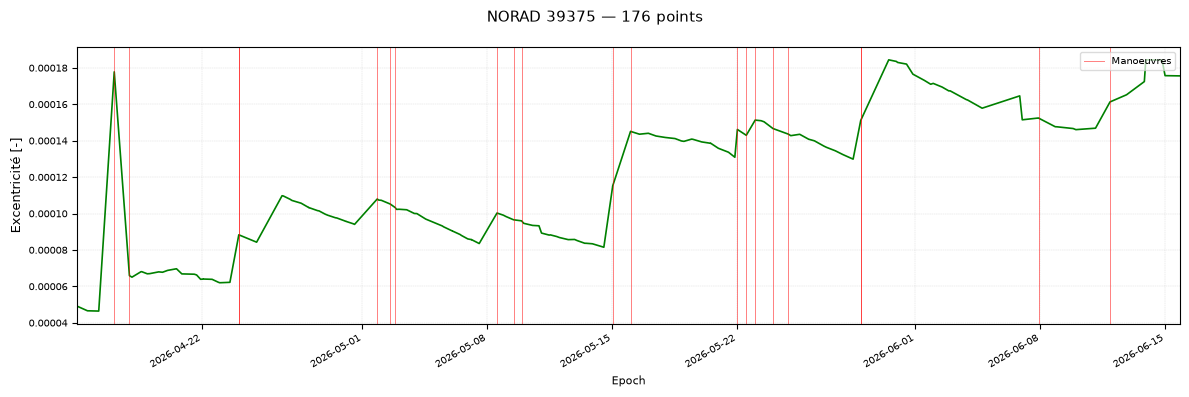

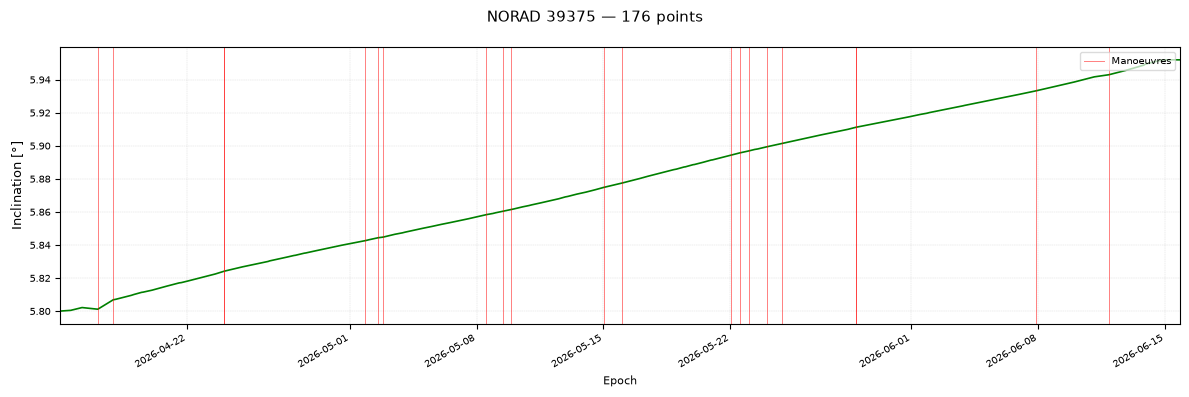

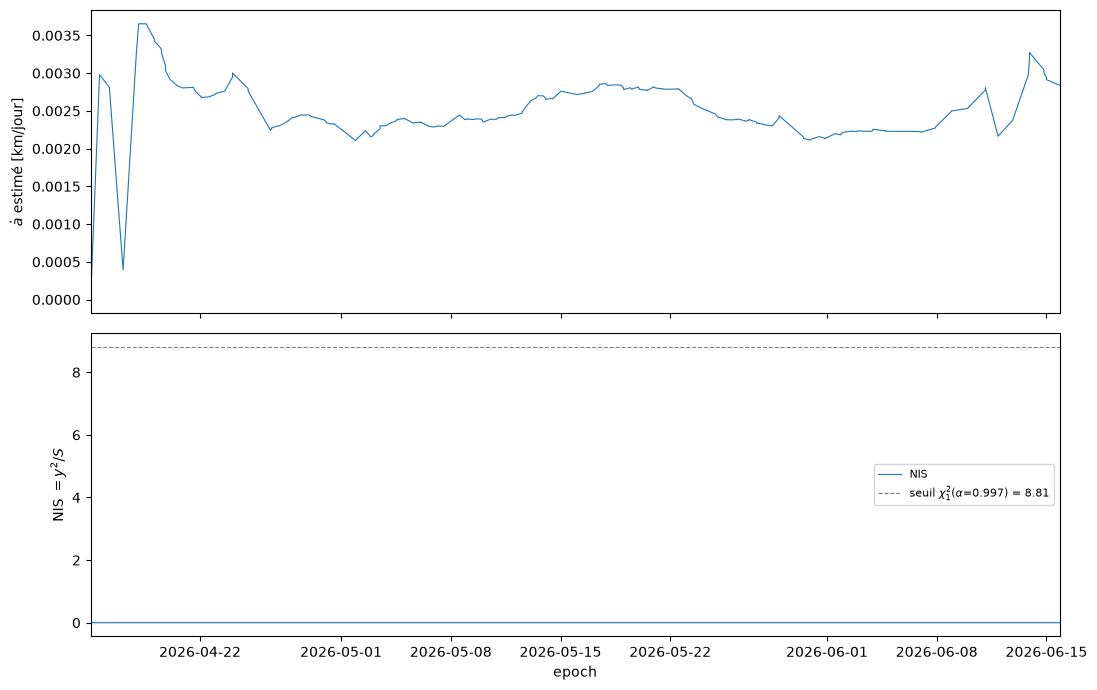

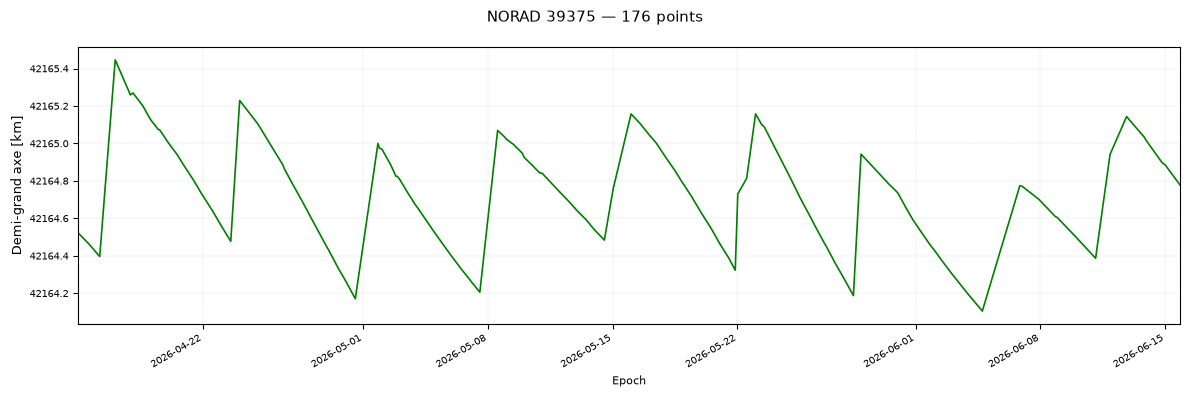

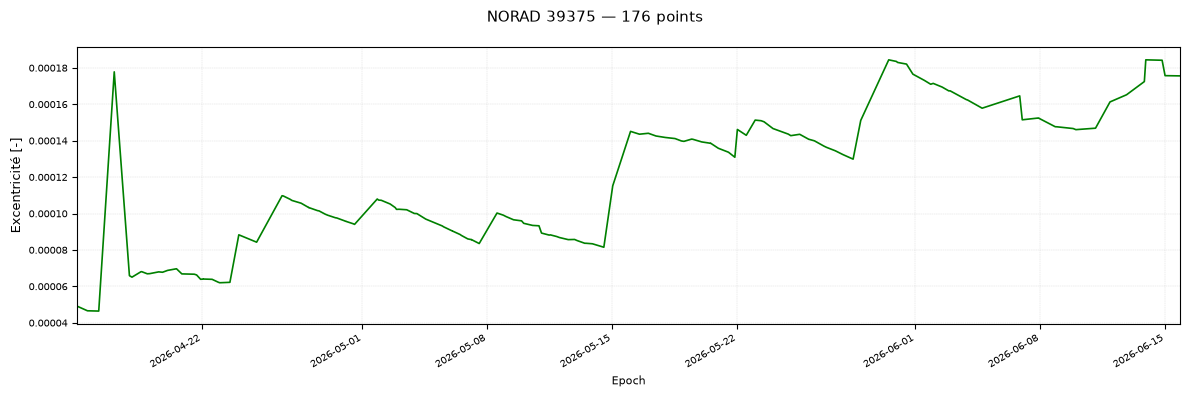

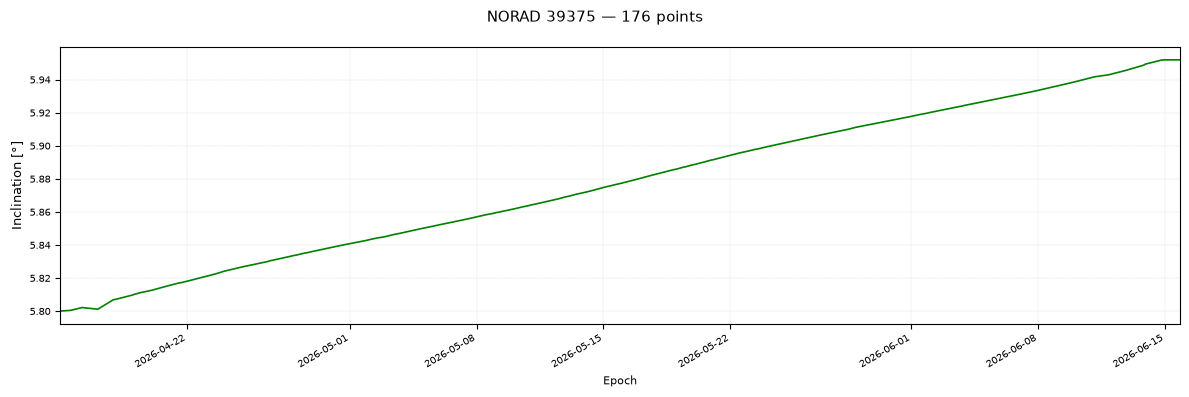

In [5]:
## RADUGA 1M-3 -  39375

path = ROOT / "data" / "raw" / "RADUGA_ALL_1783347345.439167.parquet"

## incertitude sur la mesure du demi-grand-axe : 
r = 0.005 # 50 m   
alpha= 0.997
poc_new_methods(path, norad = 39375, var_Q = 0.013, r = r, alpha= alpha)


Norad 64784 in path : True
Filtre Kalman 1 appliqué...


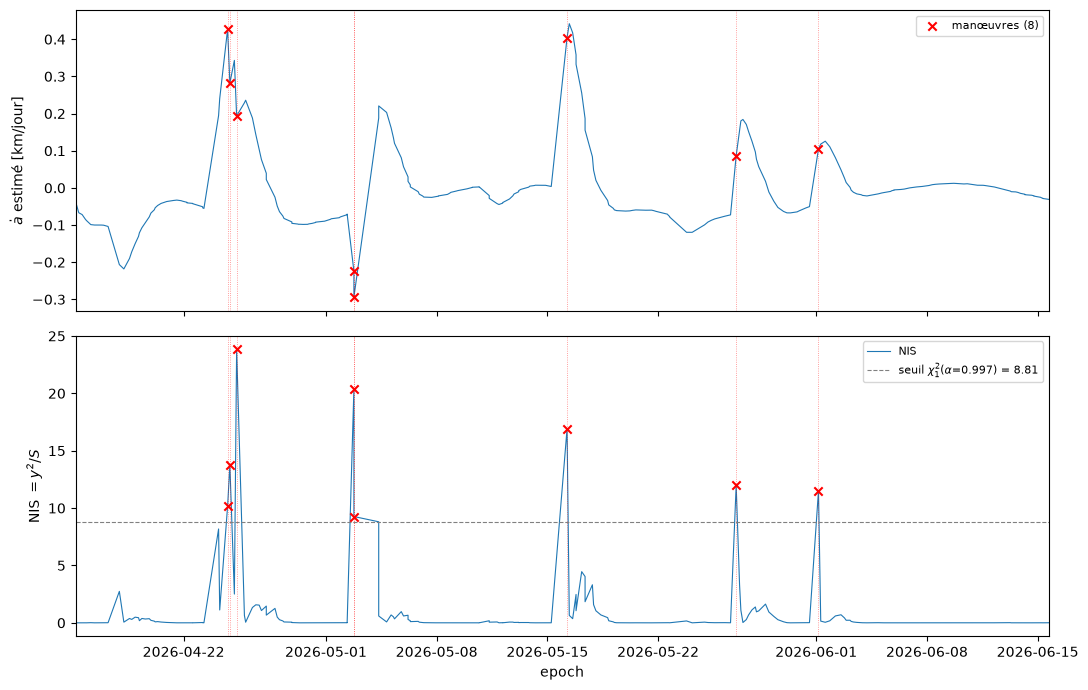

Filtre Kalman 1 appliqué...


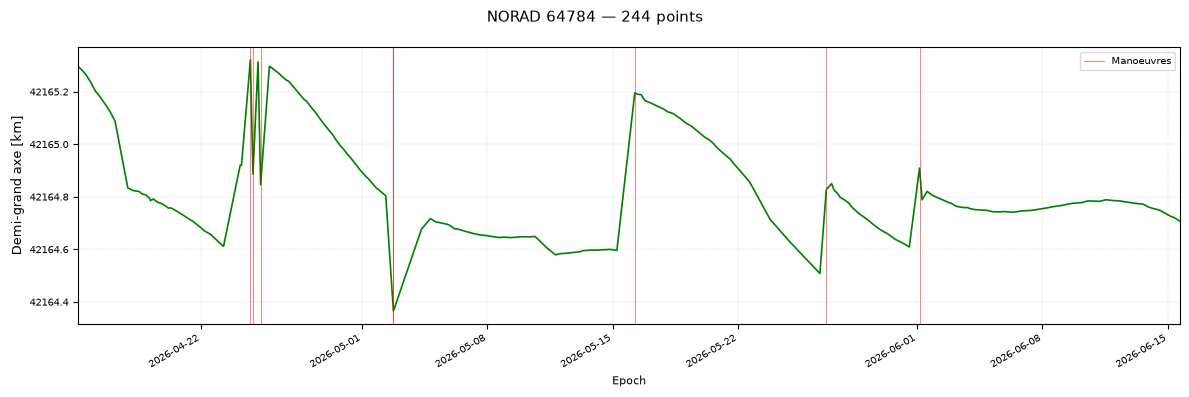

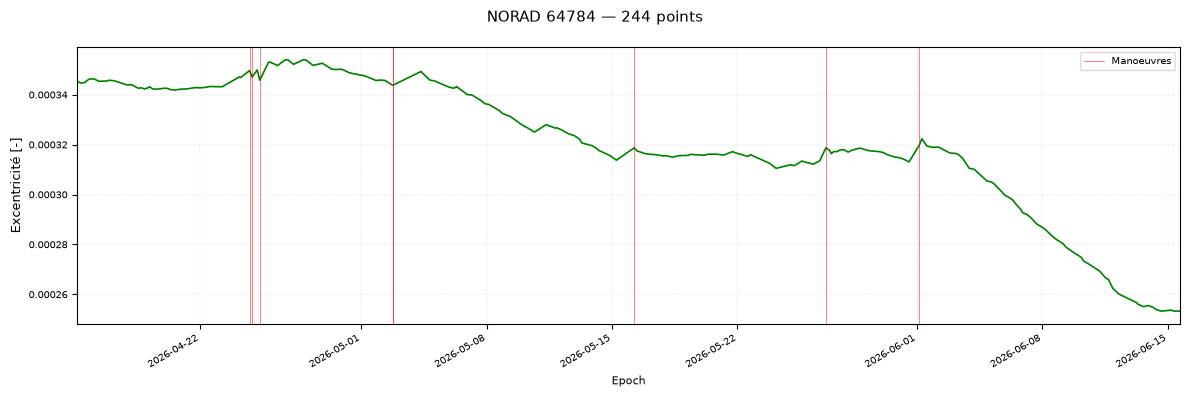

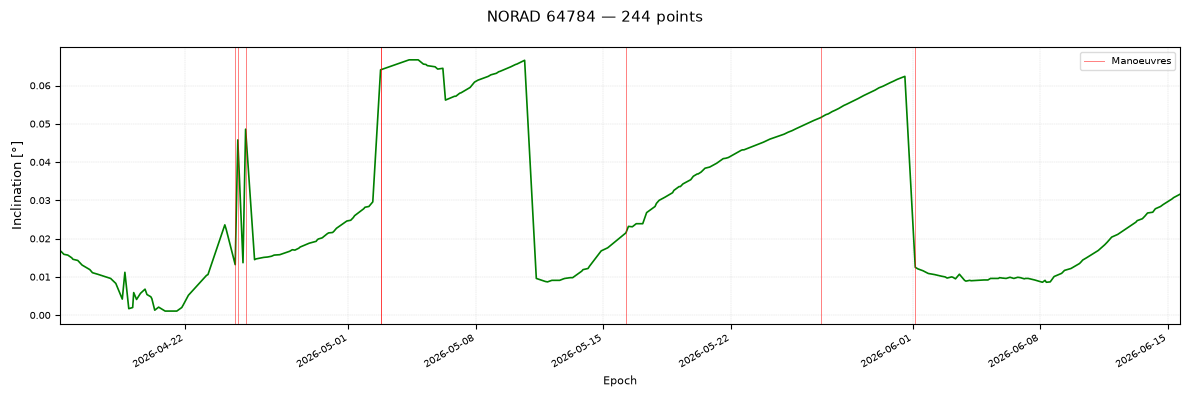

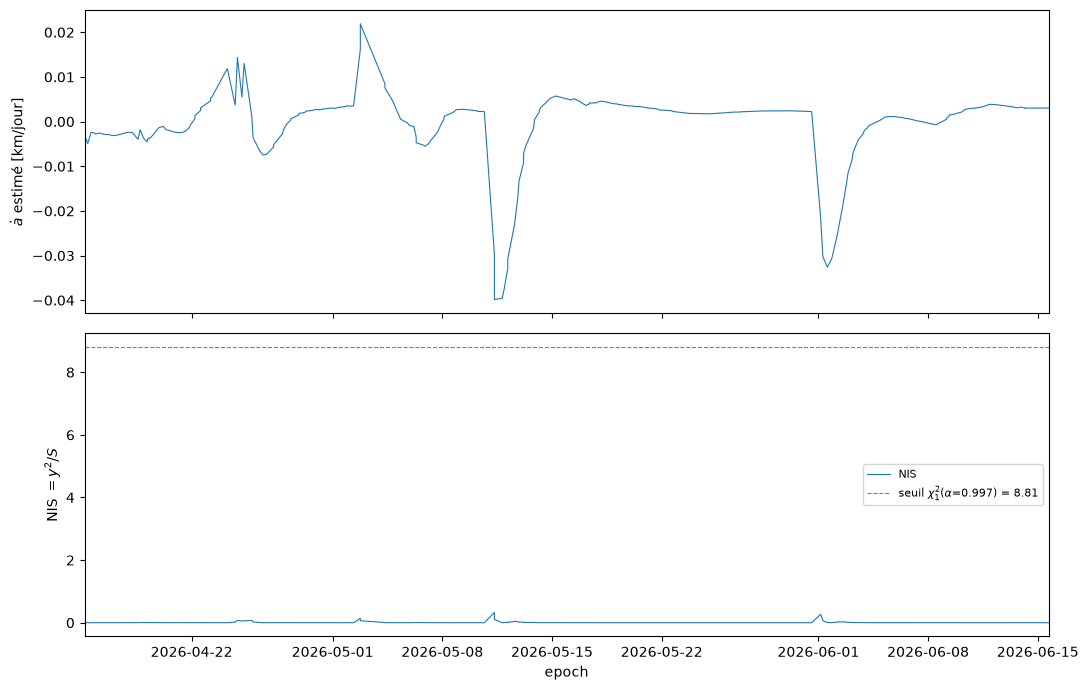

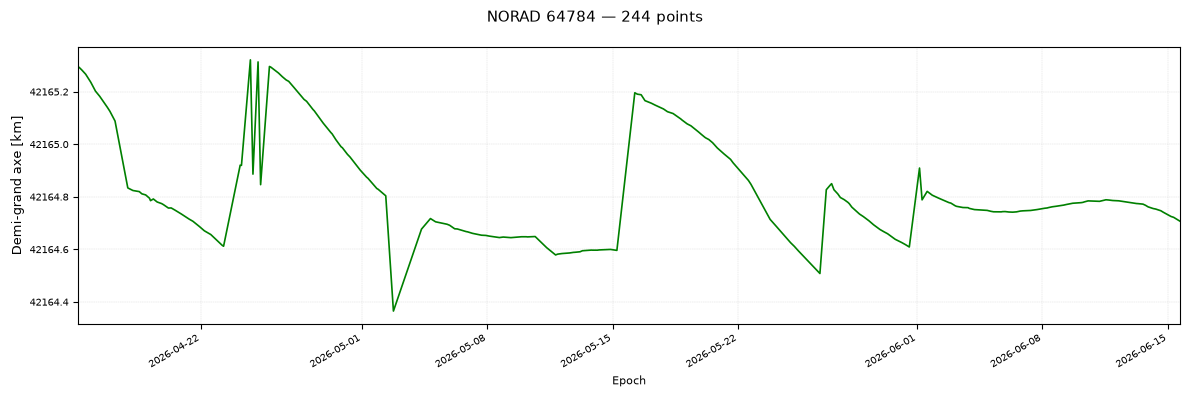

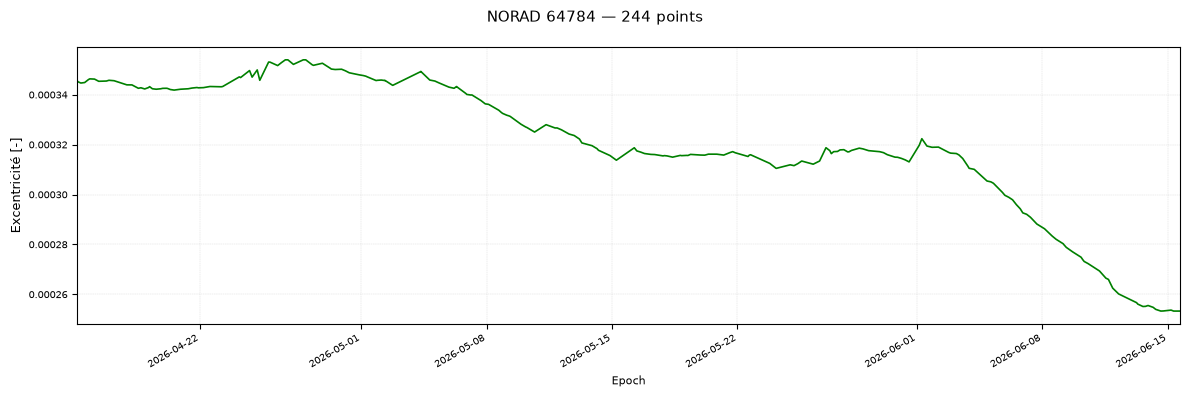

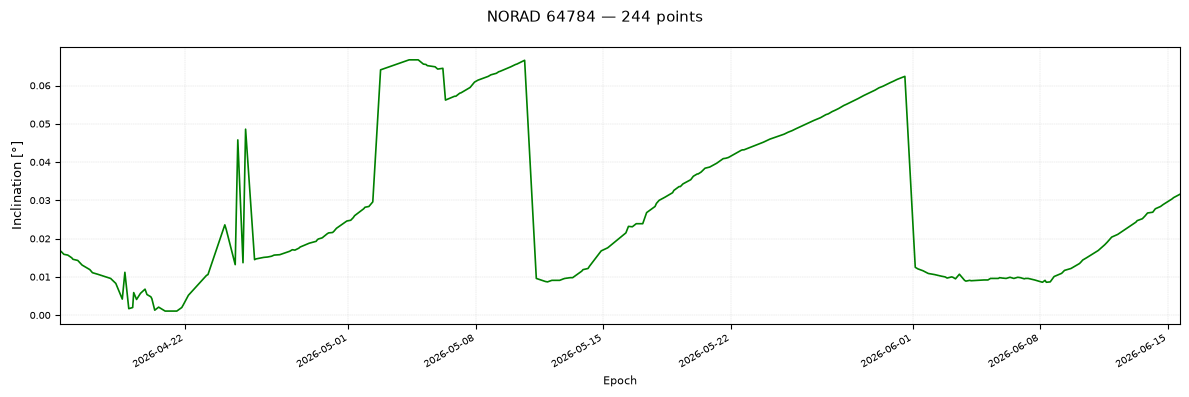

In [6]:
## DROR-1 -  64784

path = ROOT / "data" / "raw" / "DROR_ALL_1783347356.523326.parquet"

## incertitude sur la mesure du demi-grand-axe : 
r = 0.005 # 5m   
alpha= 0.997
poc_new_methods(path, norad = 64784, var_Q = 0.013, r = r, alpha= alpha)


Norad 55841 in path : True
Filtre Kalman 1 appliqué...


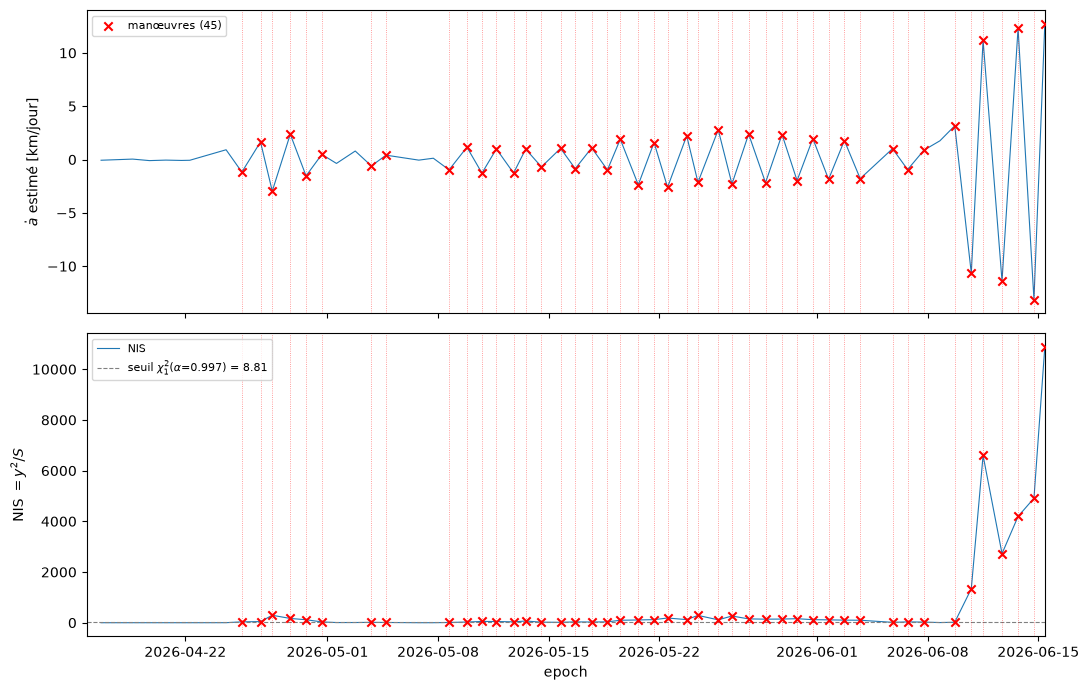

Filtre Kalman 1 appliqué...


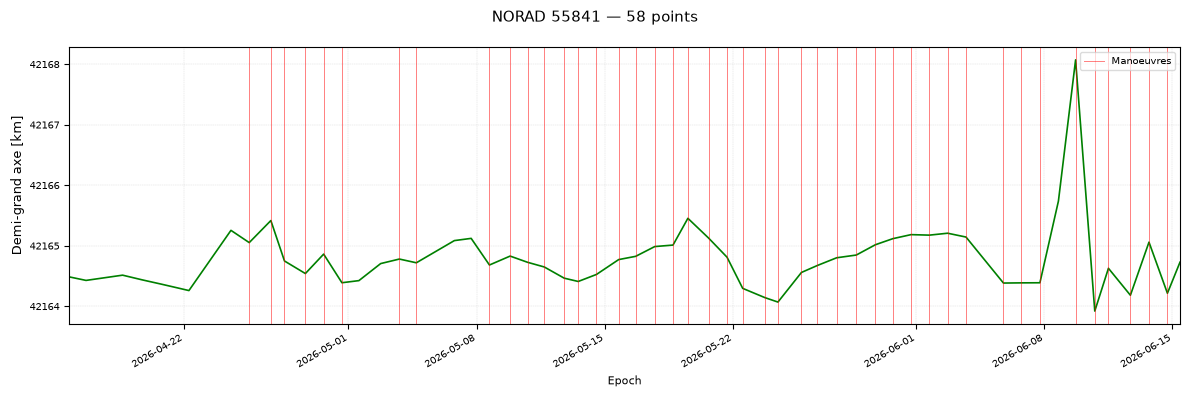

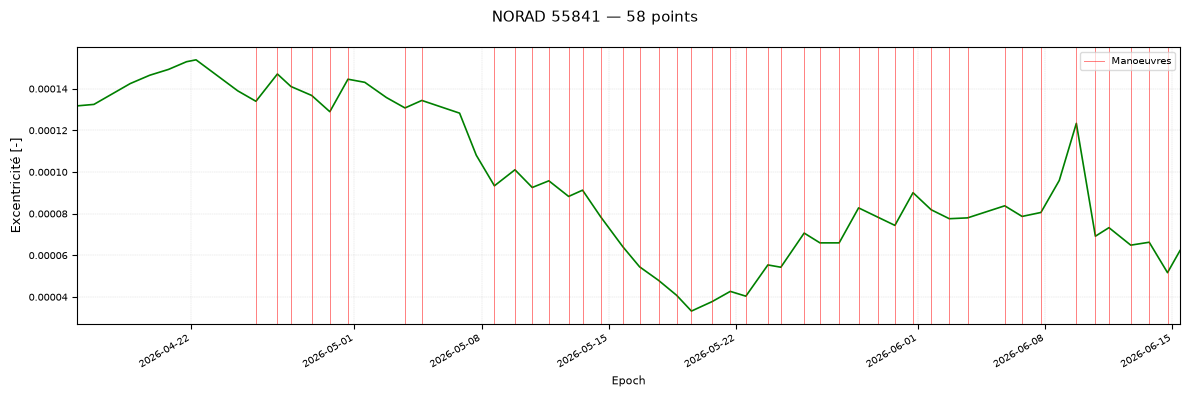

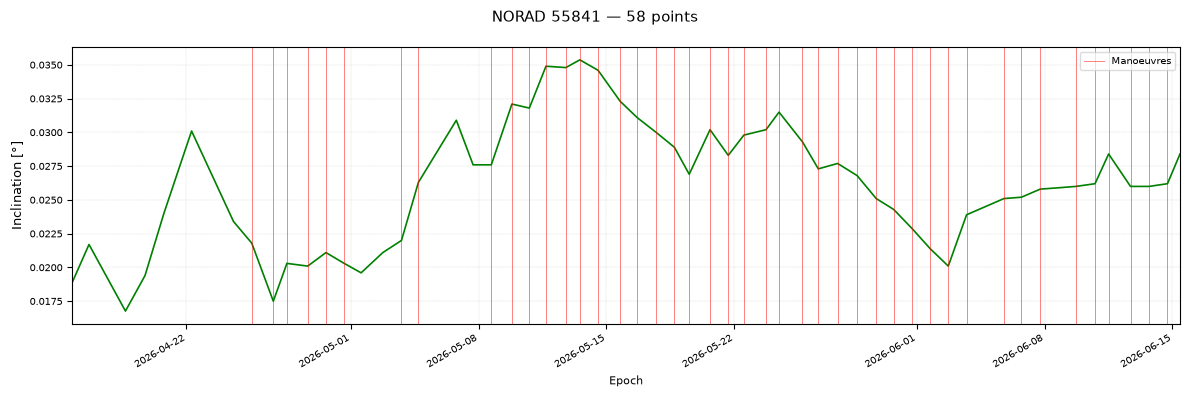

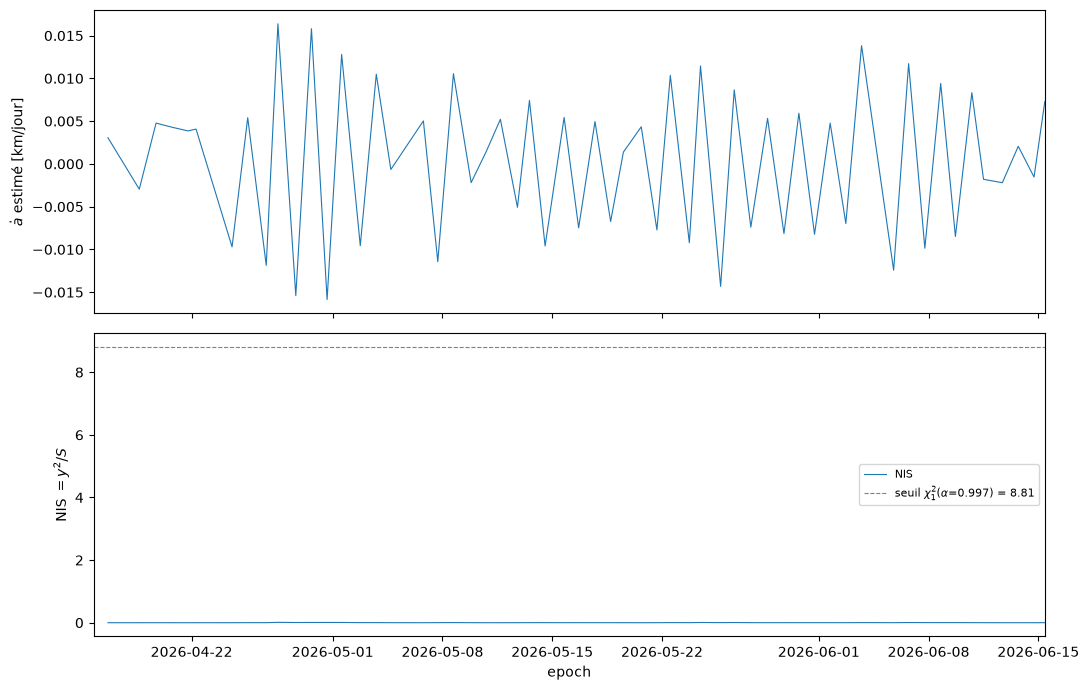

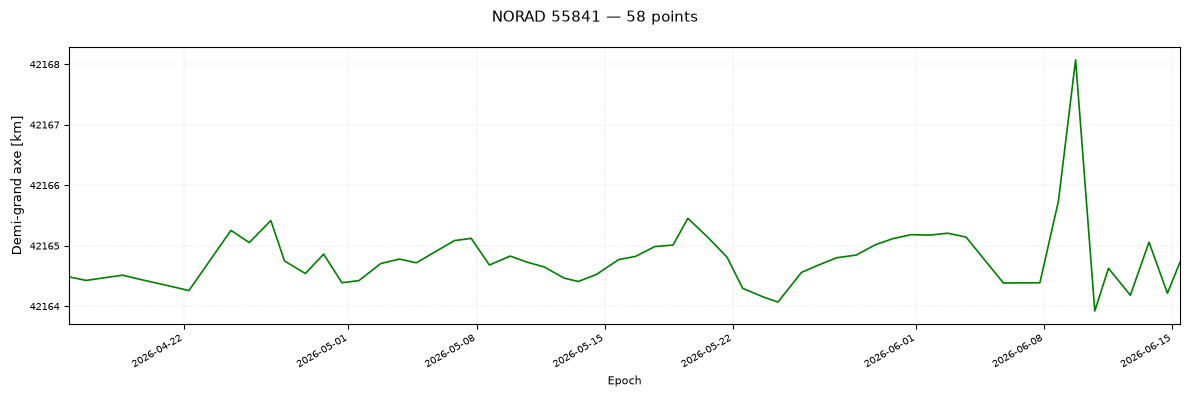

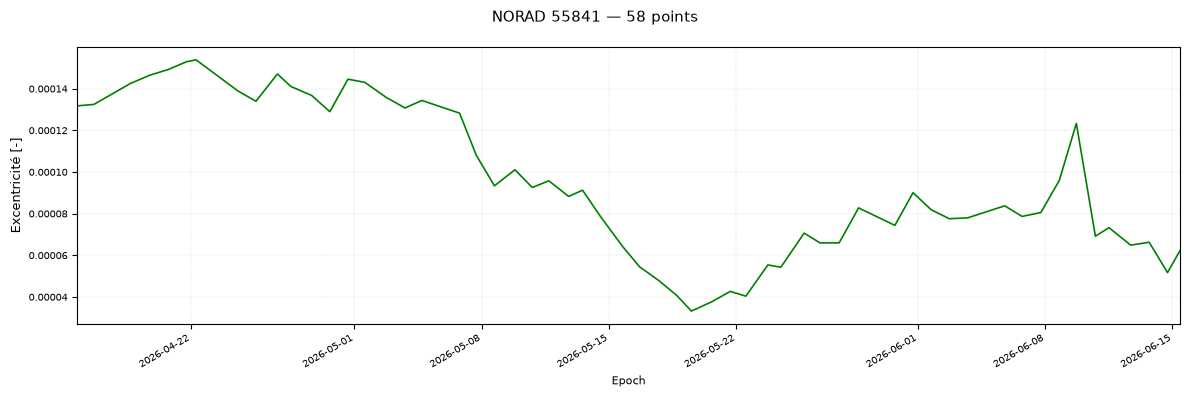

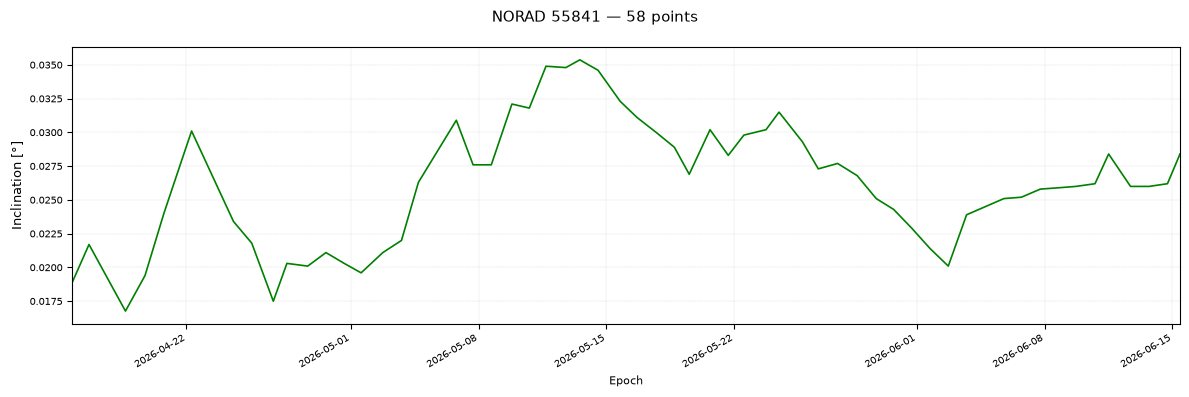

In [7]:
## LUCH (OLYMP)2 -  55841

path = ROOT / "data" / "raw" / "LUCH_ALL_1783350474.327196.parquet"

## incertitude sur la mesure du demi-grand-axe : 
r = 1e-5
alpha= 0.997
poc_new_methods(path, norad = 55841, var_Q = 0.13, r = r, alpha= alpha)


Norad 28885 in path : True
Filtre Kalman 1 appliqué...


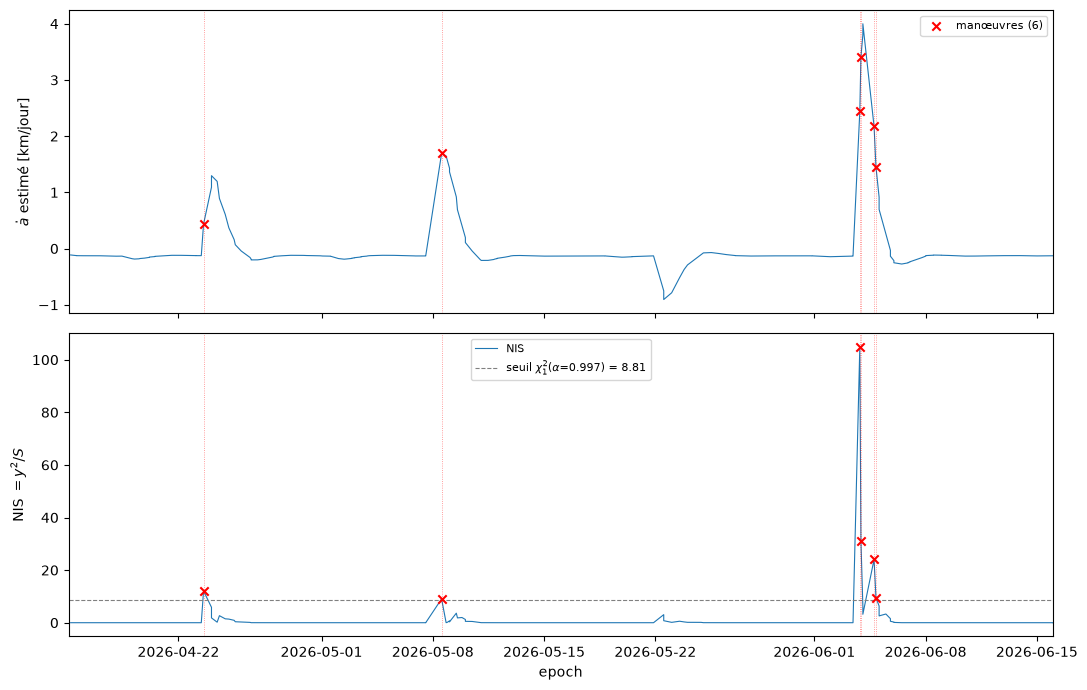

Filtre Kalman 1 appliqué...


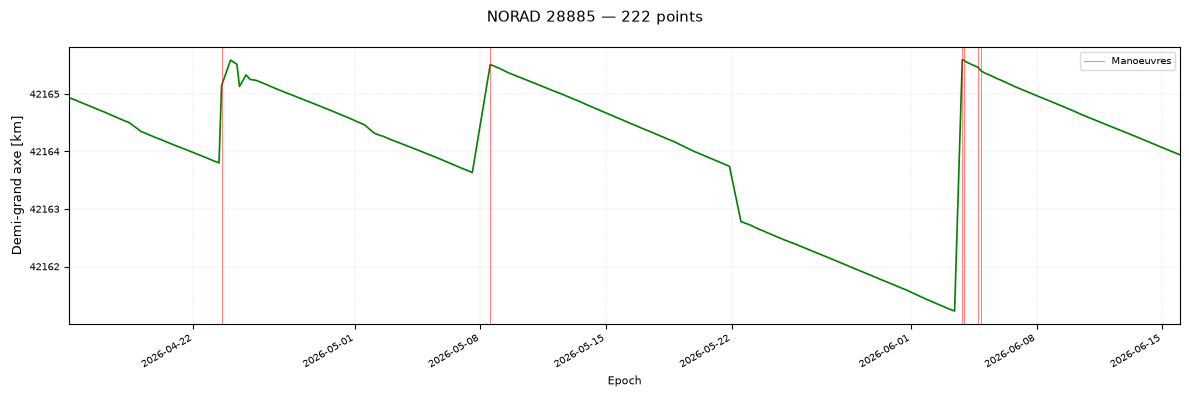

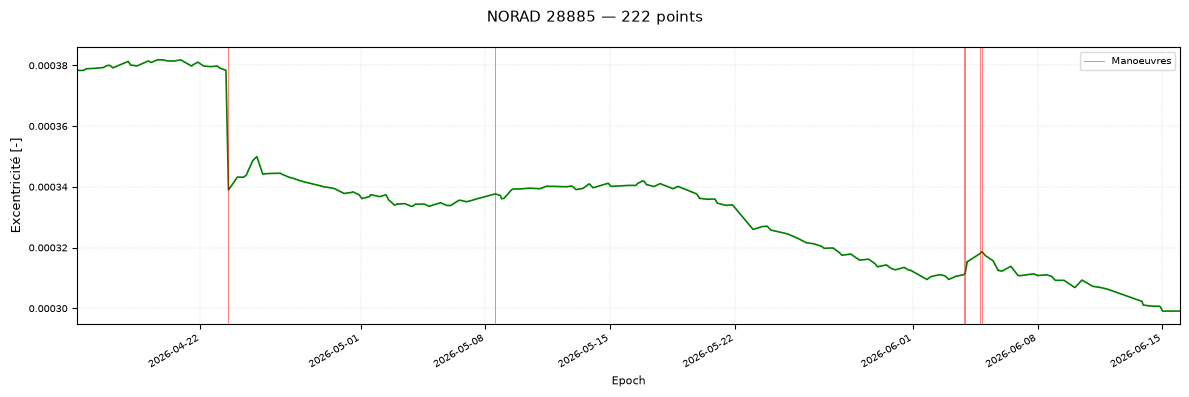

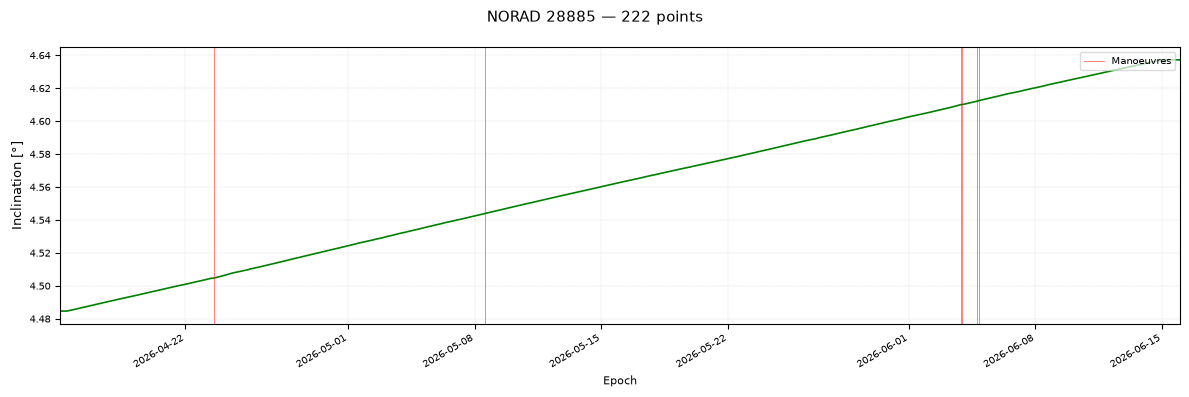

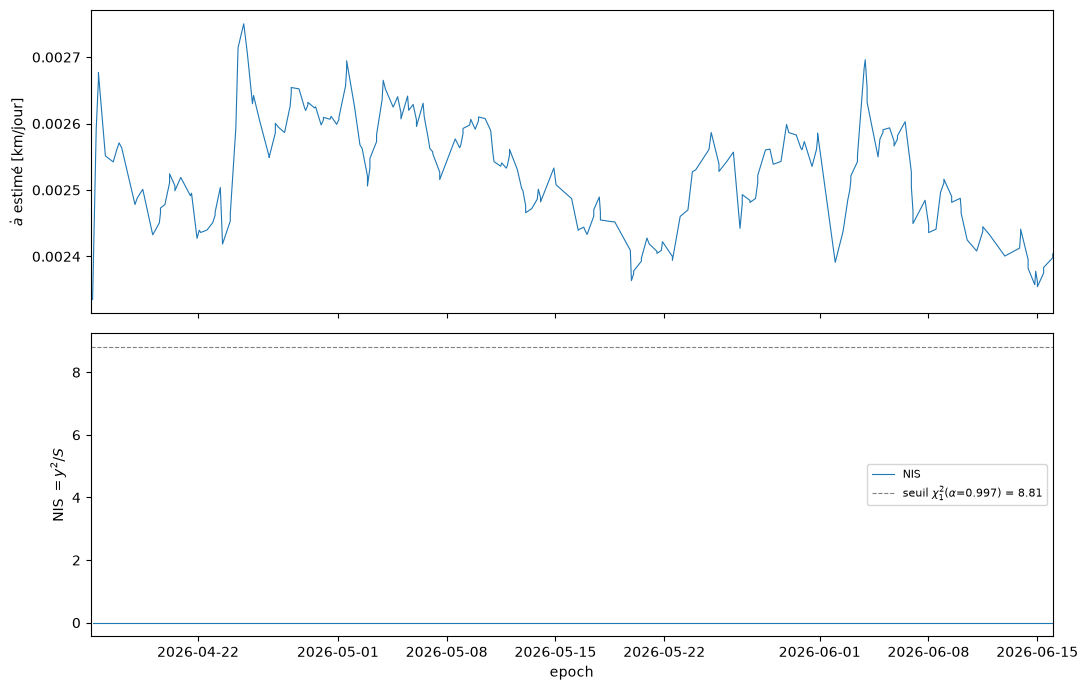

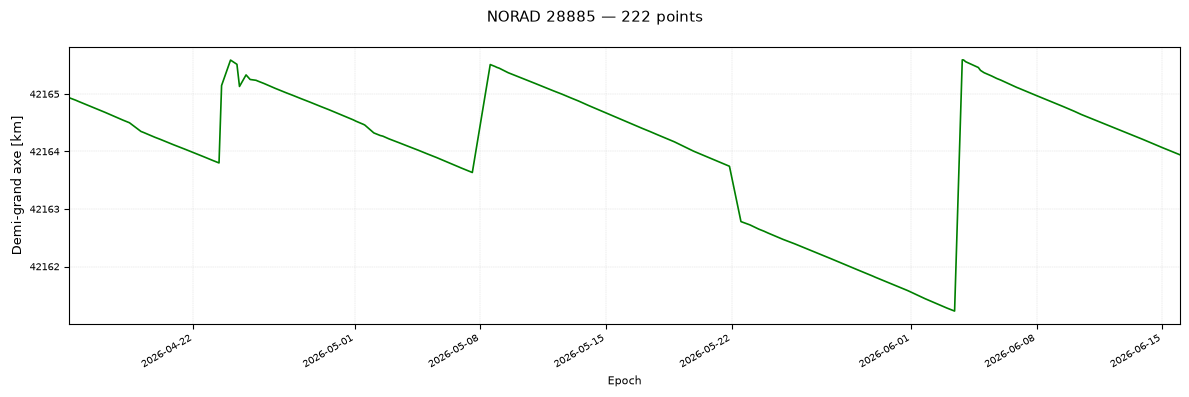

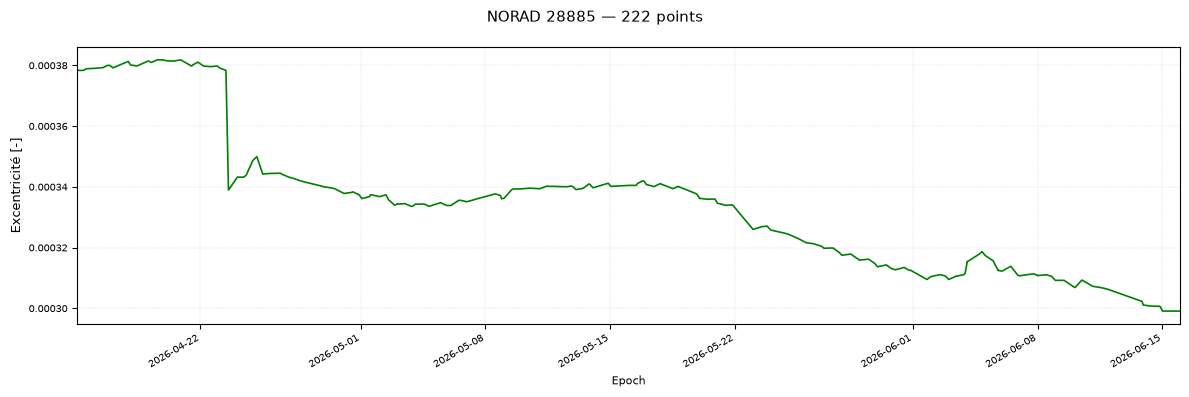

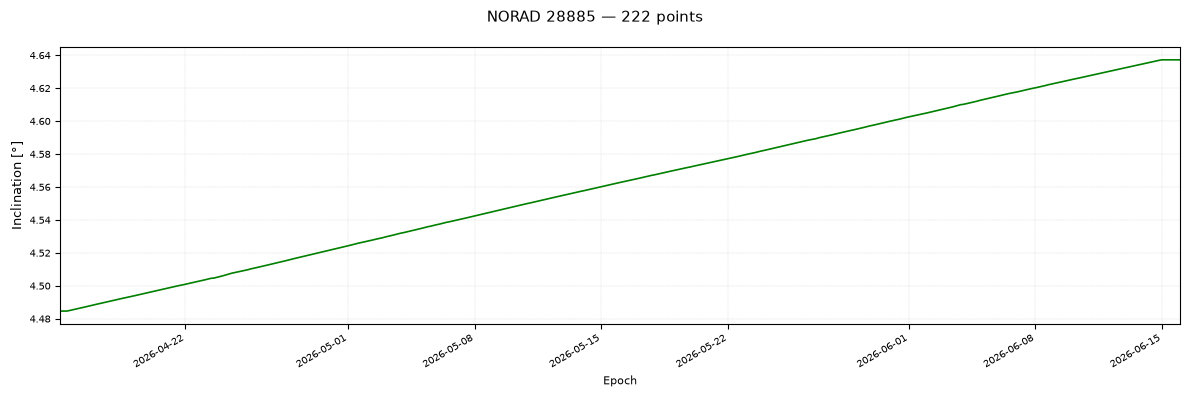

In [8]:
## SYRACUSE 3A -  28885

path = ROOT / "data" / "raw" / "SYRACUSE_ALL_1783350677.6577332.parquet"

## incertitude sur la mesure du demi-grand-axe : 
r = 0.1
alpha= 0.997
poc_new_methods(path, norad = 28885, var_Q = 0.5, r = r, alpha= alpha)


Les résultats sont très satisfaisants pour cette version 1 de notre algorithme de détection, avec des paramètres $r, varQ, p0$ et $\alpha$ qui sont pour l'instant optimisé au cas par cas (en gros en LEO : )